In [3]:
import pandas as pd
import numpy as np
import random, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [4]:
print("📂 Loading dataset...")
df = pd.read_excel("online_retail_II.xlsx")

📂 Loading dataset...


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.dropna(subset=['customer_id', 'description'], inplace=True)
df['description'] = df['description'].str.strip().str.lower()
print(f"✅ Data Loaded: {len(df)} rows")


✅ Data Loaded: 417534 rows


In [6]:
# ====================== 2. Create Transactions ======================
grouped = df.groupby(['customer_id', 'invoice'])['description'].apply(list)
transactions = grouped.values.tolist()

In [7]:
# Limit for 8GB RAM
transactions = random.sample(transactions, min(3000, len(transactions)))
print(f"✅ Transactions prepared: {len(transactions)}")

✅ Transactions prepared: 3000


In [8]:
# ====================== 3. Apriori Frequent Itemsets ======================
print("⚙️ Running Apriori (memory optimized)...")
te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

⚙️ Running Apriori (memory optimized)...


In [9]:
# Only keep top frequent 300 items to prevent memory explosion
item_freq = df_trans.sum().sort_values(ascending=False)
top_items = item_freq.head(300).index.tolist()
df_trans = df_trans[top_items]


frequent_items = apriori(df_trans, min_support=0.004, use_colnames=True, max_len=2)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)
rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)
print(f"✅ Generated {len(frequent_items)} frequent itemsets & {len(rules)} rules")


✅ Generated 1470 frequent itemsets & 583 rules


In [10]:
# ====================== 4. Build Feature Matrix ======================
itemsets = [set(x) for x in frequent_items['itemsets']]
X, y = [], []
for tx in transactions:
    tx_set = set(tx)
    features = [int(itemset.issubset(tx_set)) for itemset in itemsets]
    X.append(features)
    y.append(int(any(itemset.issubset(tx_set) for itemset in itemsets)))

X, y = np.array(X), np.array(y)
print(f"✅ Feature Matrix: {X.shape}, Label Balance: {np.bincount(y)}")

✅ Feature Matrix: (3000, 1470), Label Balance: [ 499 2501]


In [11]:
# ====================== 5. Balance Dataset ======================
print("⚖️ Balancing with SMOTE...")
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)
print(f"✅ After Balancing: {np.bincount(y_bal)}")

⚖️ Balancing with SMOTE...
✅ After Balancing: [2501 2501]


In [12]:
# ====================== 6. Prepare Models ======================
models = {
    "Hybrid_Apriori_XGBoost": XGBClassifier(max_depth=5, learning_rate=0.15, n_estimators=120,
                                            subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                                            random_state=42, n_jobs=-1, eval_metric='logloss'),
    "XGBoost": XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss'),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42)
}


In [13]:
# ====================== 7. Stratified K-Fold Cross Validation ======================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for model_name, model in models.items():
    print(f"\n🤖 Training Model: {model_name}")
    acc, prec, rec, f1s, aucs = [], [], [], [], []

    fold = 1
    for train_idx, test_idx in skf.split(X_bal, y_bal):
        X_train, X_test = X_bal[train_idx], X_bal[test_idx]
        y_train, y_test = y_bal[train_idx], y_bal[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            aucs.append(auc(fpr, tpr))
        else:
            y_prob = None
            aucs.append(0)

        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred))
        rec.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))

        print(f"Fold {fold}: Accuracy={acc[-1]*100:.2f}% | F1={f1s[-1]*100:.2f}%")
        fold += 1

    results[model_name] = {
        'Accuracy': np.mean(acc),
        'Precision': np.mean(prec),
        'Recall': np.mean(rec),
        'F1': np.mean(f1s),
        'AUC': np.mean(aucs)
    }



🤖 Training Model: Hybrid_Apriori_XGBoost
Fold 1: Accuracy=88.91% | F1=87.54%
Fold 2: Accuracy=87.91% | F1=86.23%
Fold 3: Accuracy=91.10% | F1=90.23%
Fold 4: Accuracy=88.90% | F1=87.51%
Fold 5: Accuracy=86.60% | F1=84.53%

🤖 Training Model: XGBoost
Fold 1: Accuracy=92.11% | F1=91.44%
Fold 2: Accuracy=91.41% | F1=90.59%
Fold 3: Accuracy=93.10% | F1=92.59%
Fold 4: Accuracy=91.30% | F1=90.47%
Fold 5: Accuracy=90.40% | F1=89.38%

🤖 Training Model: RandomForest
Fold 1: Accuracy=97.70% | F1=97.65%
Fold 2: Accuracy=97.40% | F1=97.33%
Fold 3: Accuracy=98.50% | F1=98.48%
Fold 4: Accuracy=97.90% | F1=97.85%
Fold 5: Accuracy=97.00% | F1=96.91%

🤖 Training Model: DecisionTree
Fold 1: Accuracy=98.00% | F1=97.96%
Fold 2: Accuracy=97.30% | F1=97.23%
Fold 3: Accuracy=98.70% | F1=98.68%
Fold 4: Accuracy=98.10% | F1=98.06%
Fold 5: Accuracy=96.20% | F1=96.05%

🤖 Training Model: LogisticRegression
Fold 1: Accuracy=93.91% | F1=93.52%
Fold 2: Accuracy=92.81% | F1=92.24%
Fold 3: Accuracy=95.40% | F1=95.18%
F

In [14]:
# ====================== 8. Results Summary ======================
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)
print("\n📊 Model Performance Summary:\n", results_df)


📊 Model Performance Summary:
                         Accuracy  Precision    Recall        F1       AUC
RandomForest            0.977010        1.0  0.954018  0.976441  0.999800
DecisionTree            0.976609        1.0  0.953216  0.975969  0.976608
LogisticRegression      0.934427        1.0  0.868849  0.929630  1.000000
XGBoost                 0.916633        1.0  0.833263  0.908944  0.975010
Hybrid_Apriori_XGBoost  0.886846        1.0  0.773689  0.872095  0.968013


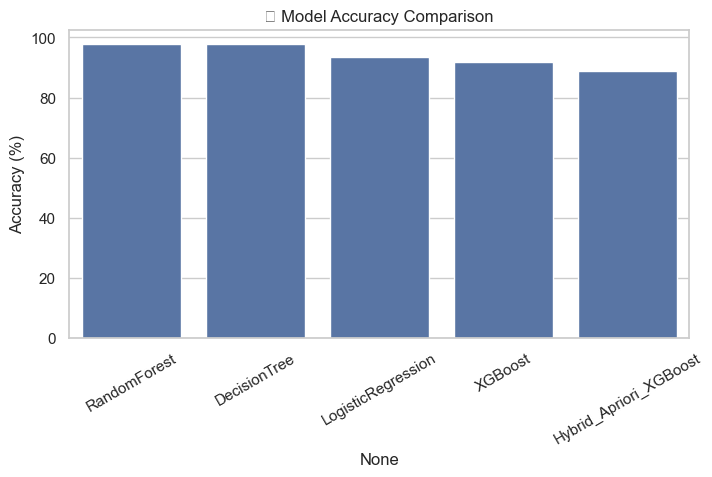

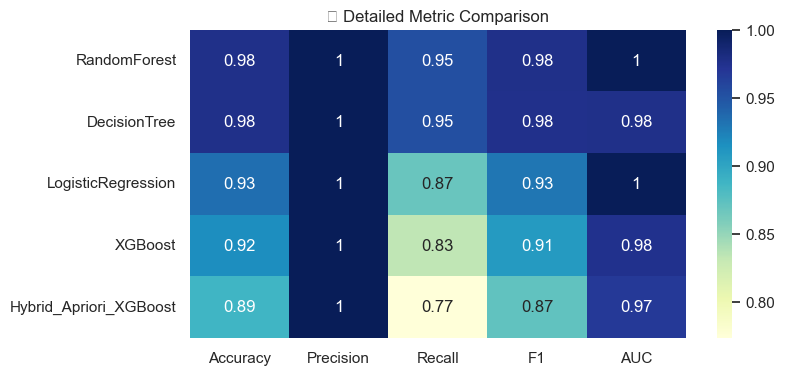

In [15]:
# ====================== 9. Visualization ======================
plt.figure(figsize=(8, 4))
sns.barplot(x=results_df.index, y=results_df['Accuracy'] * 100)
plt.title("📈 Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']], annot=True, cmap='YlGnBu')
plt.title("🔥 Detailed Metric Comparison")
plt.show()


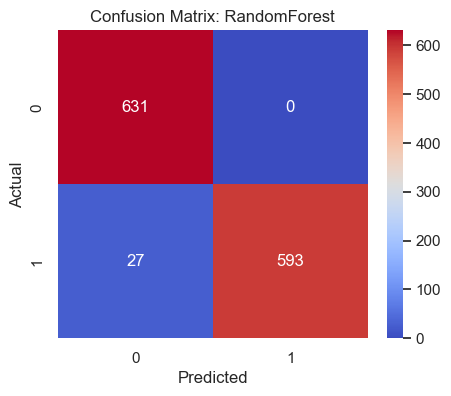


🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       631
           1       1.00      0.96      0.98       620

    accuracy                           0.98      1251
   macro avg       0.98      0.98      0.98      1251
weighted avg       0.98      0.98      0.98      1251



In [16]:
# ====================== 10. Confusion Matrix for Best Model ======================
best_model_name = results_df.index[0]
best_model = models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.25, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n🧾 Classification Report:\n", classification_report(y_test, y_pred))

In [17]:
# ====================== 11. Feature Importances (Hybrid only) ======================
if best_model_name == "Hybrid_Apriori_XGBoost":
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-10:]
    plt.figure(figsize=(8, 4))
    plt.barh(range(10), importances[top_idx], color='teal')
    plt.yticks(range(10), [', '.join(list(frequent_items.iloc[i]['itemsets'])) for i in top_idx])
    plt.xlabel("Importance")
    plt.title("Top 10 Frequent Itemset Importances")
    plt.show()

print("\n✅ All models evaluated successfully.")


✅ All models evaluated successfully.
